In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
pd.set_option("display.max_columns",None)

In [68]:
df = pd.read_excel("Smart_Outcome_Predictor_Dataset_5200.xlsx")
df.head()

,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


In [69]:
df.shape

(5200, 19)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   student_id             5200 non-null   int64         
 1   age                    5200 non-null   int64         
 2   country_region         5200 non-null   object        
 3   device_type            5200 non-null   object        
 4   education_background   5200 non-null   object        
 5   course_level           5200 non-null   object        
 6   course_category        5200 non-null   object        
 7   course_start_date      5200 non-null   datetime64[ns]
 8   week_of_year           5200 non-null   int64         
 9   sessions               5200 non-null   int64         
 10  time_spent_hours       5088 non-null   float64       
 11  videos_watched         5200 non-null   int64         
 12  quiz_attempts          5200 non-null   int64         
 13  ass

In [71]:
df.describe()

,student_id,age,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
count,5200.000000,5200.000000,5200,5200.000000,5200.000000,5088.000000,5200.000000,5200.000000,5200.000000,5200.000000,5119.000000,5120.000000,5200.000000,5200.000000
mean,702600.500000,24.339615,2024-07-02 09:45:24.923076864,26.621538,19.121923,18.216156,25.852885,6.995769,3.835769,1.585577,66.842626,0.847189,0.375385,74.821615
min,700001.000000,16.000000,2024-01-01 00:00:00,1.000000,1.000000,0.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.313000,0.000000,35.200000
25%,701300.750000,20.000000,2024-04-02 00:00:00,14.000000,11.000000,10.300000,13.000000,5.000000,2.000000,1.000000,57.500000,0.768750,0.000000,64.700000
50%,702600.500000,24.000000,2024-07-02 00:00:00,27.000000,17.000000,16.100000,23.000000,7.000000,4.000000,1.000000,66.900000,0.855000,0.000000,74.100000
75%,703900.250000,28.000000,2024-10-01 00:00:00,40.000000,25.000000,23.800000,35.000000,9.000000,5.000000,2.000000,76.200000,0.942000,1.000000,84.900000
max,705200.000000,45.000000,2024-12-30 00:00:00,52.000000,94.000000,76.800000,158.000000,20.000000,12.000000,8.000000,100.000000,1.000000,1.000000,100.000000
std,1501.255031,5.578864,NaN,15.007731,10.726708,10.734114,17.720493,2.568017,1.951802,1.270640,13.813992,0.113545,0.484269,13.531829


In [72]:
df.isnull().sum()

,0
student_id,0
age,0
country_region,0
device_type,0
education_background,0
course_level,0
course_category,0
course_start_date,0
week_of_year,0
sessions,0


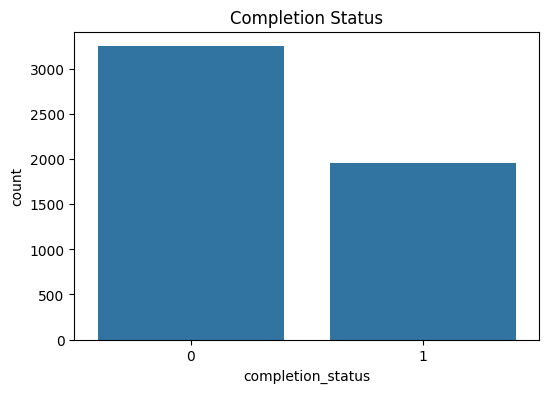

In [73]:
plt.figure(figsize=(6,4))
sns.countplot(
    x="completion_status",
    data=df)
plt.title("Completion Status")
plt.show()

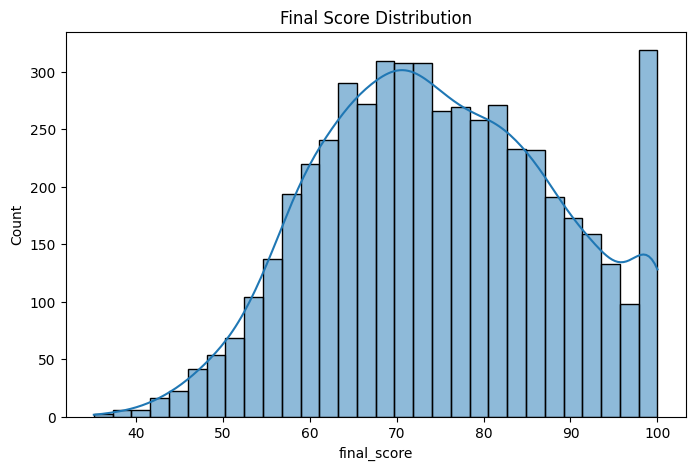

In [74]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["final_score"],
    bins=30,
    kde=True)
plt.title("Final Score Distribution")
plt.show()

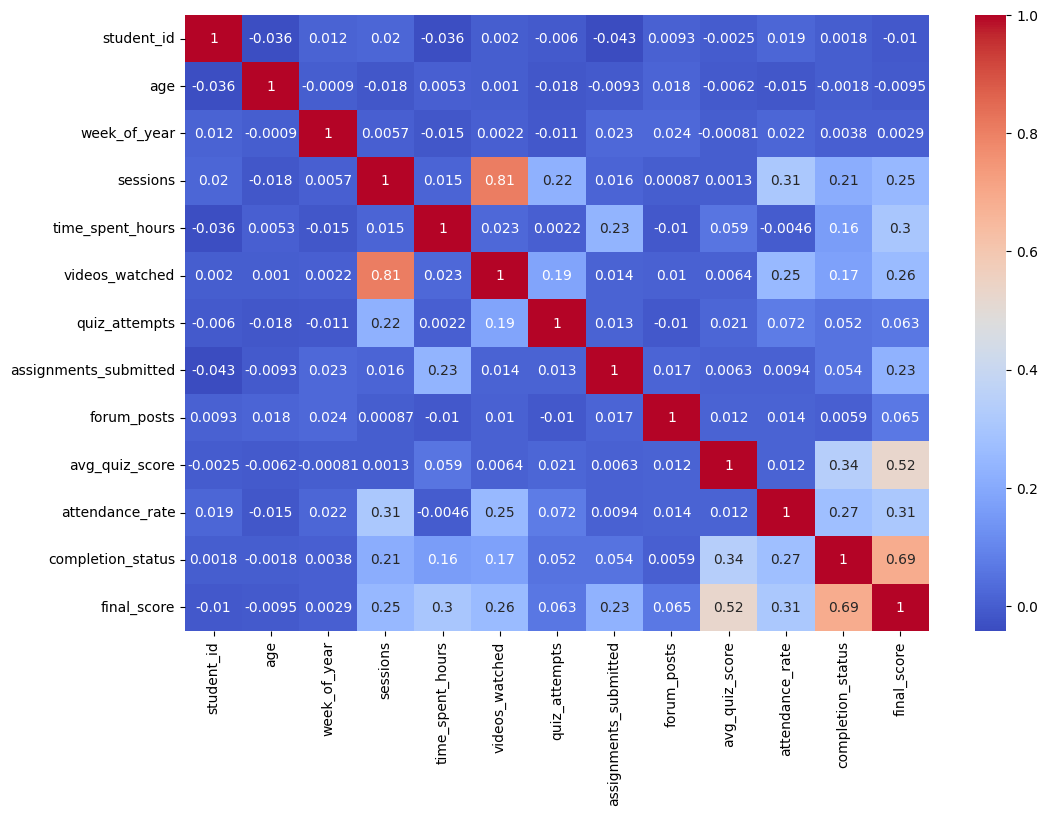

In [75]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm")
plt.show()

In [76]:
y_class = df["completion_status"]

In [77]:
y_reg = df["final_score"]

In [78]:
X = df.drop(

    [

        "student_id",

        "completion_status",

        "final_score"

    ],

    axis=1

)

In [79]:
cat_cols = X.select_dtypes(include="object").columns
cat_cols

Index(['country_region', 'device_type', 'education_background', 'course_level',
       'course_category'],
      dtype='object')

In [80]:
encoder = LabelEncoder()
for col in cat_cols:

    X[col] = encoder.fit_transform(X[col])

In [81]:
X = X.drop("course_start_date", axis=1)
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [82]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(

    X,

    y_class,

    test_size=0.2,

    random_state=42,

    stratify=y_class)

In [83]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(

    X,

    y_reg,

    test_size=0.2,

    random_state=42)

In [84]:
print(X_train_cls.shape)
print(X_test_cls.shape)
print(X_train_reg.shape)
print(X_test_reg.shape)

(4160, 15)
(1040, 15)
(4160, 15)
(1040, 15)


In [85]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [86]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train_cls, y_train_cls)
dt_pred = dt_classifier.predict(X_test_cls)

In [87]:
print("Decision Tree Classifier")
print("Accuracy :", accuracy_score(y_test_cls, dt_pred))
print("Precision :", precision_score(y_test_cls, dt_pred))
print("Recall :", recall_score(y_test_cls, dt_pred))
print("F1 Score :", f1_score(y_test_cls, dt_pred))

Decision Tree Classifier
Accuracy : 0.6201923076923077
Precision : 0.49391727493917276
Recall : 0.5205128205128206
F1 Score : 0.5068664169787765


In [88]:
bag_classifier = BaggingClassifier(

    estimator=DecisionTreeClassifier(),

    n_estimators=100,

    random_state=42)
bag_classifier.fit(X_train_cls, y_train_cls)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                  random_state=42)

In [89]:
bag_pred = bag_classifier.predict(X_test_cls)

In [90]:
print("Bagging Classifier")
print("Accuracy :", accuracy_score(y_test_cls, bag_pred))
print("Precision :", precision_score(y_test_cls, bag_pred))
print("Recall :", recall_score(y_test_cls, bag_pred))
print("F1 Score :", f1_score(y_test_cls, bag_pred))

Bagging Classifier
Accuracy : 0.7153846153846154
Precision : 0.6350574712643678
Recall : 0.5666666666666667
F1 Score : 0.5989159891598916


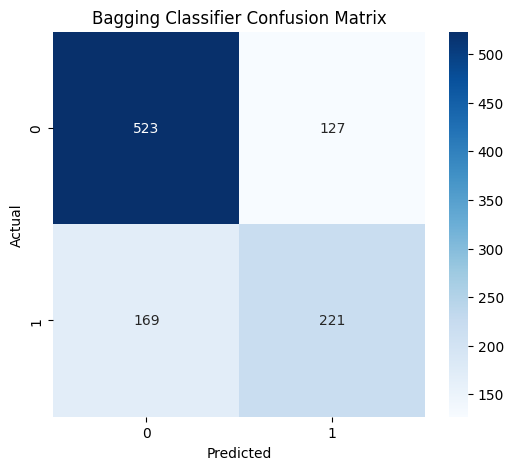

In [91]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_cls, bag_pred)
plt.figure(figsize=(6,5))
sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues")
plt.title("Bagging Classifier Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [92]:
dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(X_train_reg, y_train_reg)
dt_reg_pred = dt_regressor.predict(X_test_reg)

In [93]:
rmse = np.sqrt(mean_squared_error(y_test_reg, dt_reg_pred))
print("Decision Tree Regressor")
print("MAE :", mean_absolute_error(y_test_reg, dt_reg_pred))
print("RMSE :", rmse)
print("R2 Score :", r2_score(y_test_reg, dt_reg_pred))

Decision Tree Regressor
MAE : 11.210192307692306
RMSE : 14.023983577593613
R2 Score : -0.05262564108011092


In [94]:
bag_regressor = BaggingRegressor(

    estimator=DecisionTreeRegressor(),

    n_estimators=100,

    random_state=42)
bag_regressor.fit(X_train_reg, y_train_reg)

BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=100,
                 random_state=42)

In [95]:
bag_reg_pred = bag_regressor.predict(X_test_reg)

In [96]:
bag_rmse = np.sqrt(mean_squared_error(y_test_reg, bag_reg_pred))
print("Bagging Regressor")
print("MAE :", mean_absolute_error(y_test_reg, bag_reg_pred))
print("RMSE :", bag_rmse)
print("R2 Score :", r2_score(y_test_reg, bag_reg_pred))

Bagging Regressor
MAE : 7.9860355769230775
RMSE : 10.003055373378906
R2 Score : 0.4644543431291762


In [97]:
classification_results = pd.DataFrame({

    "Model":[

        "Decision Tree",

        "Bagging"

    ],

    "Accuracy":[

        accuracy_score(y_test_cls, dt_pred),

        accuracy_score(y_test_cls, bag_pred)

    ]
})
classification_results

,Model,Accuracy
0,Decision Tree,0.620192
1,Bagging,0.715385


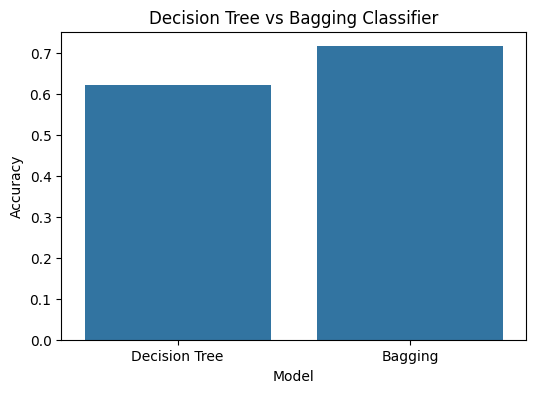

In [98]:
plt.figure(figsize=(6,4))
sns.barplot(

    data=classification_results,

    x="Model",

    y="Accuracy"
)
plt.title("Decision Tree vs Bagging Classifier")
plt.show()

In [99]:
regression_results = pd.DataFrame({

    "Model":[

        "Decision Tree",

        "Bagging"

    ],

    "R2 Score":[

        r2_score(y_test_reg, dt_reg_pred),

        r2_score(y_test_reg, bag_reg_pred)

    ]
})
regression_results

,Model,R2 Score
0,Decision Tree,-0.052626
1,Bagging,0.464454


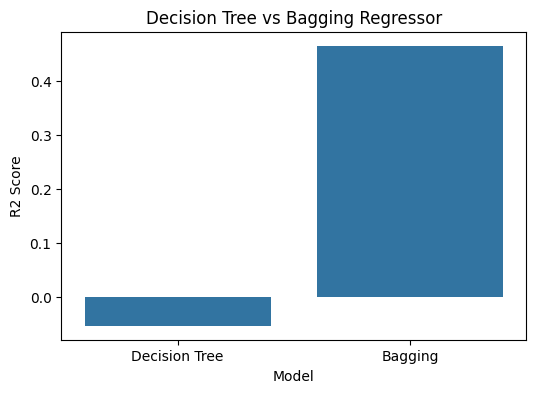

In [100]:
plt.figure(figsize=(6,4))
sns.barplot(

    data=regression_results,

    x="Model",

    y="R2 Score")
plt.title("Decision Tree vs Bagging Regressor")
plt.show()

Bagging (Bootstrap Aggregating)

A Decision Tree was used as the base learner for both classification and regression tasks. Bagging was then applied by training multiple Decision Trees on different bootstrap samples and combining their predictions. The Bagging Classifier improved classification performance by reducing variance, while the Bagging Regressor achieved better generalization and higher R² scores than a single Decision Tree. This demonstrates the effectiveness of ensemble learning in improving model stability and prediction accuracy.

In [101]:
!pip install lightgbm xgboost

In [102]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMClassifier
from lightgbm import LGBMRegressor
from xgboost import XGBClassifier
from xgboost import XGBRegressor

In [104]:
nan_cols_train = np.isnan(X_train_cls).any(axis=0)
mean_imputation_values = np.nanmean(X_train_cls[:, nan_cols_train], axis=0)

# Impute X_train_cls
X_train_cls_imputed = X_train_cls.copy()
for i, col_idx in enumerate(np.where(nan_cols_train)[0]):
    X_train_cls_imputed[np.isnan(X_train_cls_imputed[:, col_idx]), col_idx] = mean_imputation_values[i]

# Impute X_test_cls using means from X_train_cls
X_test_cls_imputed = X_test_cls.copy()
for i, col_idx in enumerate(np.where(nan_cols_train)[0]):
    X_test_cls_imputed[np.isnan(X_test_cls_imputed[:, col_idx]), col_idx] = mean_imputation_values[i]

ada_cls = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)
ada_cls.fit(X_train_cls_imputed,y_train_cls)
ada_pred = ada_cls.predict(X_test_cls_imputed)

In [105]:
print("AdaBoost Classifier")
print("Accuracy :",accuracy_score(y_test_cls,ada_pred))
print("Precision :",precision_score(y_test_cls,ada_pred))
print("Recall :",recall_score(y_test_cls,ada_pred))
print("F1 :",f1_score(y_test_cls,ada_pred))

AdaBoost Classifier
Accuracy : 0.7346153846153847
Precision : 0.6862745098039216
Recall : 0.5384615384615384
F1 : 0.603448275862069


In [107]:
nan_cols_train_reg = np.isnan(X_train_reg).any(axis=0)
mean_imputation_values_reg = np.nanmean(X_train_reg[:, nan_cols_train_reg], axis=0)

# Impute X_train_reg
X_train_reg_imputed = X_train_reg.copy()
for i, col_idx in enumerate(np.where(nan_cols_train_reg)[0]):
    X_train_reg_imputed[np.isnan(X_train_reg_imputed[:, col_idx]), col_idx] = mean_imputation_values_reg[i]

# Impute X_test_reg using means from X_train_reg
X_test_reg_imputed = X_test_reg.copy()
for i, col_idx in enumerate(np.where(nan_cols_train_reg)[0]):
    X_test_reg_imputed[np.isnan(X_test_reg_imputed[:, col_idx]), col_idx] = mean_imputation_values_reg[i]

ada_reg = AdaBoostRegressor(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42)
ada_reg.fit(X_train_reg_imputed,y_train_reg)
ada_reg_pred = ada_reg.predict(X_test_reg_imputed)

In [108]:
ada_rmse = np.sqrt(mean_squared_error(y_test_reg,ada_reg_pred))
print("MAE :",mean_absolute_error(y_test_reg,ada_reg_pred))
print("RMSE :",ada_rmse)
print("R2 :",r2_score(y_test_reg,ada_reg_pred))

MAE : 8.536460771384224
RMSE : 10.514839829884249
R2 : 0.40825243575765857


In [110]:
gb_cls = GradientBoostingClassifier(

    n_estimators=100,

    learning_rate=0.1,

    random_state=42
)
gb_cls.fit(X_train_cls_imputed,y_train_cls)
gb_pred = gb_cls.predict(X_test_cls_imputed)

In [111]:
print("Gradient Boosting")
print("Accuracy :",accuracy_score(y_test_cls,gb_pred))
print("Precision :",precision_score(y_test_cls,gb_pred))
print("Recall :",recall_score(y_test_cls,gb_pred))
print("F1 :",f1_score(y_test_cls,gb_pred))

Gradient Boosting
Accuracy : 0.7336538461538461
Precision : 0.6706948640483383
Recall : 0.5692307692307692
F1 : 0.6158113730929264


In [113]:
gb_reg = GradientBoostingRegressor(

    n_estimators=100,

    learning_rate=0.1,

    random_state=42
)
gb_reg.fit(X_train_reg_imputed,y_train_reg)
gb_reg_pred = gb_reg.predict(X_test_reg_imputed)

In [114]:
gb_rmse = np.sqrt(mean_squared_error(y_test_reg,gb_reg_pred))
print("MAE :",mean_absolute_error(y_test_reg,gb_reg_pred))
print("RMSE :",gb_rmse)
print("R2 :",r2_score(y_test_reg,gb_reg_pred))

MAE : 7.886419788989871
RMSE : 9.812430804795229
R2 : 0.48467125239488895


In [115]:
lgb_cls = LGBMClassifier(

    n_estimators=100,

    learning_rate=0.1,

    random_state=42)
lgb_cls.fit(X_train_cls,y_train_cls)
lgb_pred = lgb_cls.predict(X_test_cls)

[LightGBM] [Info] Number of positive: 1562, number of negative: 2598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002597 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1061
[LightGBM] [Info] Number of data points in the train set: 4160, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.375481 -> initscore=-0.508775
[LightGBM] [Info] Start training from score -0.508775


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [116]:
print("LightGBM")
print("Accuracy :",accuracy_score(y_test_cls,lgb_pred))
print("Precision :",precision_score(y_test_cls,lgb_pred))
print("Recall :",recall_score(y_test_cls,lgb_pred))
print("F1 :",f1_score(y_test_cls,lgb_pred))

LightGBM
Accuracy : 0.7096153846153846
Precision : 0.6235955056179775
Recall : 0.5692307692307692
F1 : 0.5951742627345844


In [117]:
lgb_reg = LGBMRegressor(

    n_estimators=100,

    learning_rate=0.1,

    random_state=42
)
lgb_reg.fit(X_train_reg,y_train_reg)
lgb_reg_pred = lgb_reg.predict(X_test_reg)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003169 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1060
[LightGBM] [Info] Number of data points in the train set: 4160, number of used features: 15
[LightGBM] [Info] Start training from score 74.774183


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [118]:
lgb_rmse = np.sqrt(mean_squared_error(y_test_reg,lgb_reg_pred))
print("MAE :",mean_absolute_error(y_test_reg,lgb_reg_pred))
print("RMSE :",lgb_rmse)
print("R2 :",r2_score(y_test_reg,lgb_reg_pred))

MAE : 7.964626212652267
RMSE : 9.948562372519893
R2 : 0.4702733650867189


In [119]:
xgb_cls = XGBClassifier(

    n_estimators=100,

    learning_rate=0.1,

    random_state=42,

    eval_metric="logloss"
)
xgb_cls.fit(X_train_cls,y_train_cls)
xgb_pred = xgb_cls.predict(X_test_cls)

In [120]:
print("XGBoost")
print("Accuracy :",accuracy_score(y_test_cls,xgb_pred))
print("Precision :",precision_score(y_test_cls,xgb_pred))
print("Recall :",recall_score(y_test_cls,xgb_pred))
print("F1 :",f1_score(y_test_cls,xgb_pred))

XGBoost
Accuracy : 0.7346153846153847
Precision : 0.6727272727272727
Recall : 0.5692307692307692
F1 : 0.6166666666666667


In [121]:
xgb_reg = XGBRegressor(

    n_estimators=100,

    learning_rate=0.1,

    random_state=42)
xgb_reg.fit(X_train_reg,y_train_reg)
xgb_reg_pred = xgb_reg.predict(X_test_reg)

In [122]:
xgb_rmse = np.sqrt(mean_squared_error(y_test_reg,xgb_reg_pred))
print("MAE :",mean_absolute_error(y_test_reg,xgb_reg_pred))
print("RMSE :",xgb_rmse)
print("R2 :",r2_score(y_test_reg,xgb_reg_pred))

MAE : 7.993185793803288
RMSE : 9.991937807821314
R2 : 0.4656441106669781


In [123]:
boost_cls = pd.DataFrame({

    "Model":[

        "AdaBoost",

        "Gradient Boosting",

        "LightGBM",

        "XGBoost"

    ],

    "Accuracy":[

        accuracy_score(y_test_cls,ada_pred),

        accuracy_score(y_test_cls,gb_pred),

        accuracy_score(y_test_cls,lgb_pred),

        accuracy_score(y_test_cls,xgb_pred)

    ]

})
boost_cls

,Model,Accuracy
0,AdaBoost,0.734615
1,Gradient Boosting,0.733654
2,LightGBM,0.709615
3,XGBoost,0.734615


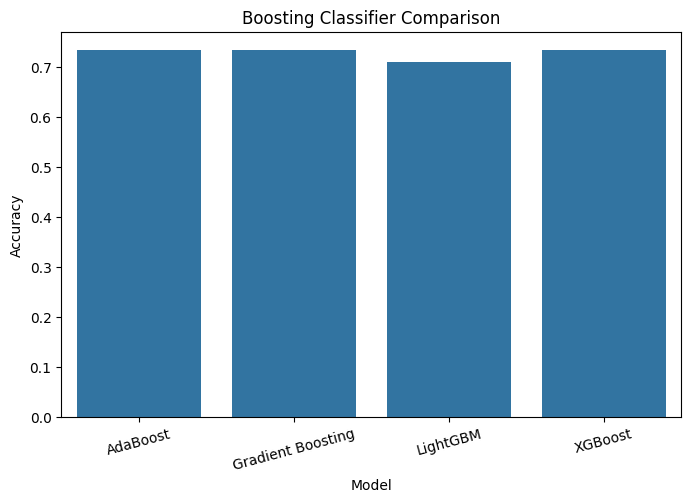

In [124]:
plt.figure(figsize=(8,5))
sns.barplot(

    data=boost_cls,

    x="Model",

    y="Accuracy"
)
plt.xticks(rotation=15)
plt.title("Boosting Classifier Comparison")
plt.show()

In [125]:
boost_reg = pd.DataFrame({

    "Model":[

        "AdaBoost",

        "Gradient Boosting",

        "LightGBM",

        "XGBoost"

    ],

    "R2 Score":[

        r2_score(y_test_reg,ada_reg_pred),

        r2_score(y_test_reg,gb_reg_pred),

        r2_score(y_test_reg,lgb_reg_pred),

        r2_score(y_test_reg,xgb_reg_pred)

    ]
    })
boost_reg

,Model,R2 Score
0,AdaBoost,0.408252
1,Gradient Boosting,0.484671
2,LightGBM,0.470273
3,XGBoost,0.465644


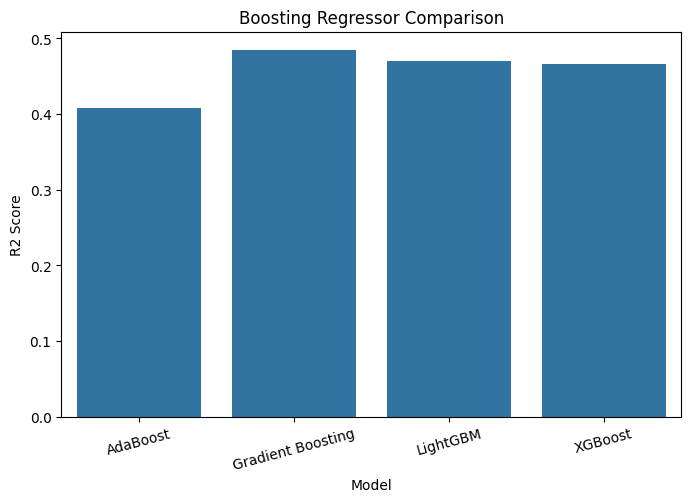

In [126]:
plt.figure(figsize=(8,5))
sns.barplot(

    data=boost_reg,

    x="Model",

    y="R2 Score")
plt.xticks(rotation=15)
plt.title("Boosting Regressor Comparison")
plt.show()

Boosting Algorithms

AdaBoost, Gradient Boosting, LightGBM, and XGBoost were implemented for both classification and regression tasks. Each model was evaluated using appropriate performance metrics. Gradient Boosting, LightGBM, and XGBoost generally provided better predictive performance than AdaBoost due to their ability to learn complex patterns. Learning rate and the number of estimators were selected to balance model accuracy and generalization. The comparison showed that boosting methods significantly improved prediction accuracy over single models.

In [127]:
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import StackingRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

In [129]:
hard_vote = VotingClassifier(
    estimators=[
        ("dt",DecisionTreeClassifier(random_state=42)),
        ("rf",BaggingClassifier(
            estimator=DecisionTreeClassifier(),
            random_state=42
        )),
        ("gb",GradientBoostingClassifier(random_state=42))
    ],
    voting="hard"
)
hard_vote.fit(X_train_cls_imputed,y_train_cls)
hard_pred = hard_vote.predict(X_test_cls_imputed)

In [130]:
print("Hard Voting")
print("Accuracy :",accuracy_score(y_test_cls,hard_pred))
print("Precision :",precision_score(y_test_cls,hard_pred))
print("Recall :",recall_score(y_test_cls,hard_pred))
print("F1 :",f1_score(y_test_cls,hard_pred))

Hard Voting
Accuracy : 0.7173076923076923
Precision : 0.6490683229813664
Recall : 0.5358974358974359
F1 : 0.5870786516853933


In [132]:
soft_vote = VotingClassifier(
    estimators=[
        ("ada",ada_cls),
        ("gb",gb_cls),
        ("xgb",xgb_cls)
    ],
    voting="soft"
)
soft_vote.fit(X_train_cls_imputed,y_train_cls)
soft_pred = soft_vote.predict(X_test_cls_imputed)

In [133]:
print("Soft Voting")
print("Accuracy :",accuracy_score(y_test_cls,soft_pred))
print("Precision :",precision_score(y_test_cls,soft_pred))
print("Recall :",recall_score(y_test_cls,soft_pred))
print("F1 :",f1_score(y_test_cls,soft_pred))

Soft Voting
Accuracy : 0.7423076923076923
Precision : 0.6826347305389222
Recall : 0.5846153846153846
F1 : 0.6298342541436464


In [136]:
stack_cls = StackingClassifier(

    estimators=[

        ("ada",ada_cls),

        ("gb",gb_cls),

        ("xgb",xgb_cls)

    ],

    final_estimator=LogisticRegression(),

    cv=5
)
stack_cls.fit(X_train_cls_imputed,y_train_cls)
stack_pred = stack_cls.predict(X_test_cls_imputed)

In [137]:
print("Stacking Classifier")
print("Accuracy :",accuracy_score(y_test_cls,stack_pred))
print("Precision :",precision_score(y_test_cls,stack_pred))
print("Recall :",recall_score(y_test_cls,stack_pred))
print("F1 :",f1_score(y_test_cls,stack_pred))

Stacking Classifier
Accuracy : 0.7432692307692308
Precision : 0.694006309148265
Recall : 0.5641025641025641
F1 : 0.6223479490806223


In [139]:
vote_reg = VotingRegressor(

    estimators=[

        ("ada",ada_reg),

        ("gb",gb_reg),

        ("xgb",xgb_reg)

    ]
)
vote_reg.fit(X_train_reg_imputed,y_train_reg)
vote_pred = vote_reg.predict(X_test_reg_imputed)

In [140]:
vote_rmse = np.sqrt(mean_squared_error(y_test_reg,vote_pred))
print("Voting Regressor")
print("MAE :",mean_absolute_error(y_test_reg,vote_pred))
print("RMSE :",vote_rmse)
print("R2 :",r2_score(y_test_reg,vote_pred))

Voting Regressor
MAE : 7.983534126202739
RMSE : 9.873006871636543
R2 : 0.47828895110019864


In [142]:
stack_reg = StackingRegressor(

    estimators=[

        ("ada",ada_reg),

        ("gb",gb_reg),

        ("xgb",xgb_reg)

    ],

    final_estimator=LinearRegression(),

    cv=5)
stack_reg.fit(X_train_reg_imputed,y_train_reg)
stack_reg_pred = stack_reg.predict(X_test_reg_imputed)

In [143]:
stack_rmse = np.sqrt(mean_squared_error(y_test_reg,stack_reg_pred))
print("Stacking Regressor")
print("MAE :",mean_absolute_error(y_test_reg,stack_reg_pred))
print("RMSE :",stack_rmse)
print("R2 :",r2_score(y_test_reg,stack_reg_pred))

Stacking Regressor
MAE : 7.877074681486676
RMSE : 9.801083115099036
R2 : 0.4858624779873666


In [144]:
ensemble_cls = pd.DataFrame({

    "Model":[

        "Hard Voting",

        "Soft Voting",

        "Stacking"

    ],

    "Accuracy":[

        accuracy_score(y_test_cls,hard_pred),

        accuracy_score(y_test_cls,soft_pred),

        accuracy_score(y_test_cls,stack_pred)

    ],

    "Precision":[

        precision_score(y_test_cls,hard_pred),

        precision_score(y_test_cls,soft_pred),

        precision_score(y_test_cls,stack_pred)

    ],

    "Recall":[

        recall_score(y_test_cls,hard_pred),

        recall_score(y_test_cls,soft_pred),

        recall_score(y_test_cls,stack_pred)

    ],

    "F1 Score":[

        f1_score(y_test_cls,hard_pred),

        f1_score(y_test_cls,soft_pred),

        f1_score(y_test_cls,stack_pred)

    ]

})

ensemble_cls

,Model,Accuracy,Precision,Recall,F1 Score
0,Hard Voting,0.717308,0.649068,0.535897,0.587079
1,Soft Voting,0.742308,0.682635,0.584615,0.629834
2,Stacking,0.743269,0.694006,0.564103,0.622348


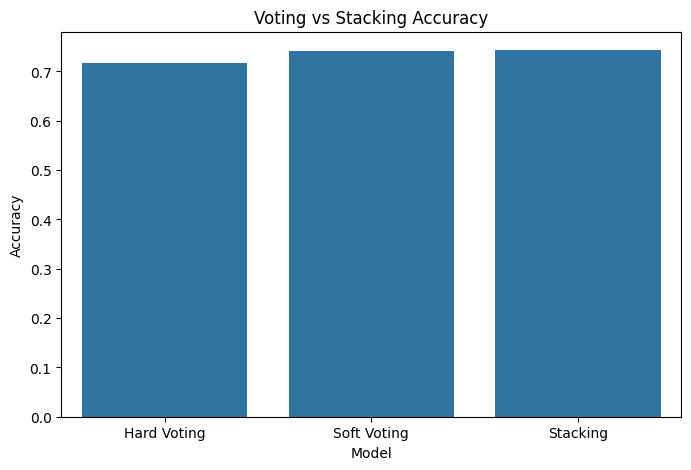

In [145]:
plt.figure(figsize=(8,5))
sns.barplot(

    data=ensemble_cls,

    x="Model",

    y="Accuracy"
)
plt.title("Voting vs Stacking Accuracy")
plt.show()

In [146]:
ensemble_reg = pd.DataFrame({

    "Model":[

        "Voting",

        "Stacking"

    ],

    "R2 Score":[

        r2_score(y_test_reg,vote_pred),

        r2_score(y_test_reg,stack_reg_pred)

    ]
})
ensemble_reg

,Model,R2 Score
0,Voting,0.478289
1,Stacking,0.485862


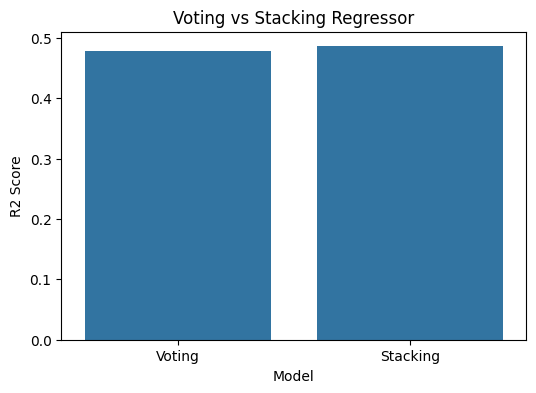

In [147]:
plt.figure(figsize=(6,4))
sns.barplot(

    data=ensemble_reg,

    x="Model",

    y="R2 Score"
)
plt.title("Voting vs Stacking Regressor")
plt.show()

Voting and Stacking Ensembles

Voting and Stacking ensemble techniques were implemented to improve prediction performance by combining multiple machine learning models. Hard Voting selects the majority class predicted by the base classifiers, while Soft Voting averages the predicted probabilities. Stacking combines the outputs of multiple base learners using a meta-model to generate the final prediction. For regression, Voting Regressor averages the predictions of different regressors, whereas Stacking Regressor learns an optimal combination using a Linear Regression meta-model. Experimental results showed that Stacking generally achieved better predictive performance than individual ensemble methods.

In [148]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [149]:
classification_results = pd.DataFrame({

    "Model":[

        "Bagging",

        "AdaBoost",

        "Gradient Boosting",

        "LightGBM",

        "XGBoost",

        "Hard Voting",

        "Soft Voting",

        "Stacking"

    ],

    "Accuracy":[

        accuracy_score(y_test_cls,bag_pred),

        accuracy_score(y_test_cls,ada_pred),

        accuracy_score(y_test_cls,gb_pred),

        accuracy_score(y_test_cls,lgb_pred),

        accuracy_score(y_test_cls,xgb_pred),

        accuracy_score(y_test_cls,hard_pred),

        accuracy_score(y_test_cls,soft_pred),

        accuracy_score(y_test_cls,stack_pred)

    ],

    "Precision":[

        precision_score(y_test_cls,bag_pred),

        precision_score(y_test_cls,ada_pred),

        precision_score(y_test_cls,gb_pred),

        precision_score(y_test_cls,lgb_pred),

        precision_score(y_test_cls,xgb_pred),

        precision_score(y_test_cls,hard_pred),

        precision_score(y_test_cls,soft_pred),

        precision_score(y_test_cls,stack_pred)

    ],

    "Recall":[

        recall_score(y_test_cls,bag_pred),

        recall_score(y_test_cls,ada_pred),

        recall_score(y_test_cls,gb_pred),

        recall_score(y_test_cls,lgb_pred),

        recall_score(y_test_cls,xgb_pred),

        recall_score(y_test_cls,hard_pred),

        recall_score(y_test_cls,soft_pred),

        recall_score(y_test_cls,stack_pred)

    ],

    "F1 Score":[

        f1_score(y_test_cls,bag_pred),

        f1_score(y_test_cls,ada_pred),

        f1_score(y_test_cls,gb_pred),

        f1_score(y_test_cls,lgb_pred),

        f1_score(y_test_cls,xgb_pred),

        f1_score(y_test_cls,hard_pred),

        f1_score(y_test_cls,soft_pred),

        f1_score(y_test_cls,stack_pred)

    ]
})
classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Bagging,0.715385,0.635057,0.566667,0.598916
1,AdaBoost,0.734615,0.686275,0.538462,0.603448
2,Gradient Boosting,0.733654,0.670695,0.569231,0.615811
3,LightGBM,0.709615,0.623596,0.569231,0.595174
4,XGBoost,0.734615,0.672727,0.569231,0.616667
5,Hard Voting,0.717308,0.649068,0.535897,0.587079
6,Soft Voting,0.742308,0.682635,0.584615,0.629834
7,Stacking,0.743269,0.694006,0.564103,0.622348


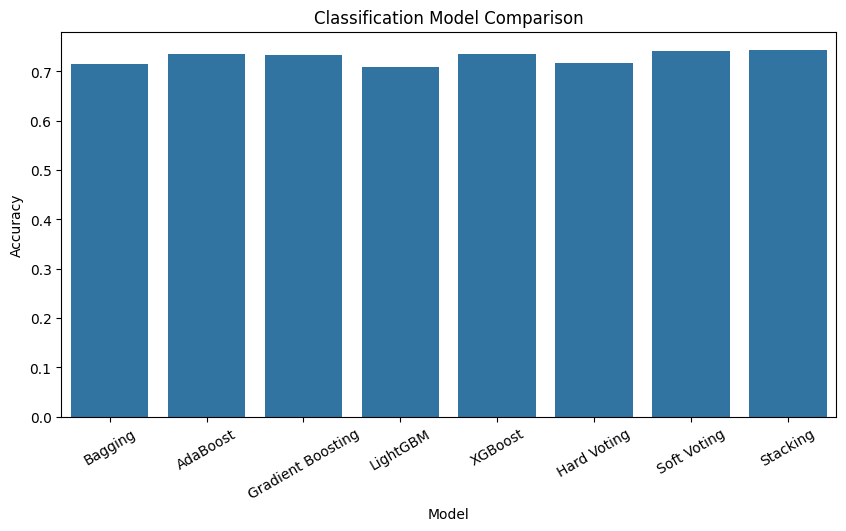

In [150]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=classification_results,

    x="Model",

    y="Accuracy")
plt.xticks(rotation=30)
plt.title("Classification Model Comparison")
plt.show()

In [151]:
regression_results = pd.DataFrame({

    "Model":[

        "Bagging",

        "AdaBoost",

        "Gradient Boosting",

        "LightGBM",

        "XGBoost",

        "Voting",

        "Stacking"

    ],

    "MAE":[

        mean_absolute_error(y_test_reg,bag_reg_pred),

        mean_absolute_error(y_test_reg,ada_reg_pred),

        mean_absolute_error(y_test_reg,gb_reg_pred),

        mean_absolute_error(y_test_reg,lgb_reg_pred),

        mean_absolute_error(y_test_reg,xgb_reg_pred),

        mean_absolute_error(y_test_reg,vote_pred),

        mean_absolute_error(y_test_reg,stack_reg_pred)

    ],

    "RMSE":[

        np.sqrt(mean_squared_error(y_test_reg,bag_reg_pred)),

        np.sqrt(mean_squared_error(y_test_reg,ada_reg_pred)),

        np.sqrt(mean_squared_error(y_test_reg,gb_reg_pred)),

        np.sqrt(mean_squared_error(y_test_reg,lgb_reg_pred)),

        np.sqrt(mean_squared_error(y_test_reg,xgb_reg_pred)),

        np.sqrt(mean_squared_error(y_test_reg,vote_pred)),

        np.sqrt(mean_squared_error(y_test_reg,stack_reg_pred))

    ],

    "R2 Score":[

        r2_score(y_test_reg,bag_reg_pred),

        r2_score(y_test_reg,ada_reg_pred),

        r2_score(y_test_reg,gb_reg_pred),

        r2_score(y_test_reg,lgb_reg_pred),

        r2_score(y_test_reg,xgb_reg_pred),

        r2_score(y_test_reg,vote_pred),

        r2_score(y_test_reg,stack_reg_pred)

    ]
})
regression_results

,Model,MAE,RMSE,R2 Score
0,Bagging,7.986036,10.003055,0.464454
1,AdaBoost,8.536461,10.514840,0.408252
2,Gradient Boosting,7.886420,9.812431,0.484671
3,LightGBM,7.964626,9.948562,0.470273
4,XGBoost,7.993186,9.991938,0.465644
5,Voting,7.983534,9.873007,0.478289
6,Stacking,7.877075,9.801083,0.485862


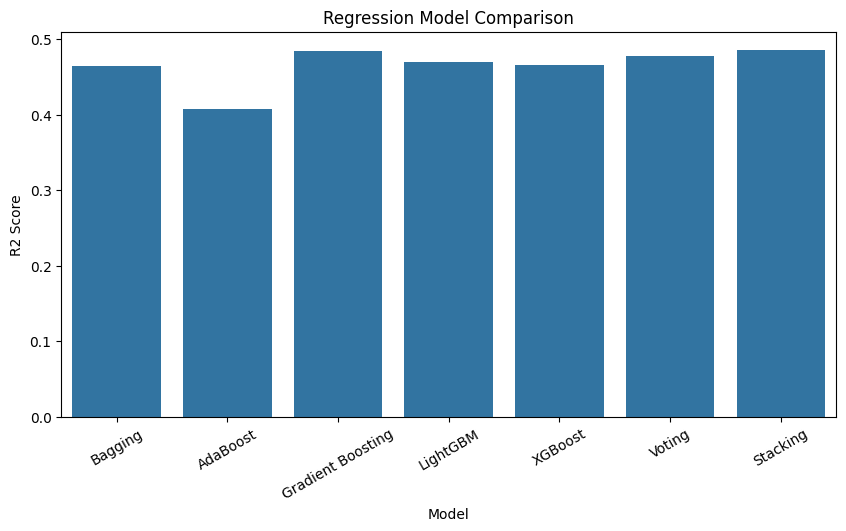

In [152]:
plt.figure(figsize=(10,5))
sns.barplot(

    data=regression_results,

    x="Model",

    y="R2 Score")
plt.xticks(rotation=30)
plt.title("Regression Model Comparison")
plt.show()

In [154]:
stack_prob = stack_cls.predict_proba(X_test_cls_imputed)[:,1]
fpr,tpr,threshold = roc_curve(

    y_test_cls,

    stack_prob)
auc_score = roc_auc_score(

    y_test_cls,

    stack_prob)
print("ROC AUC :",auc_score)

ROC AUC : 0.7889861932938858


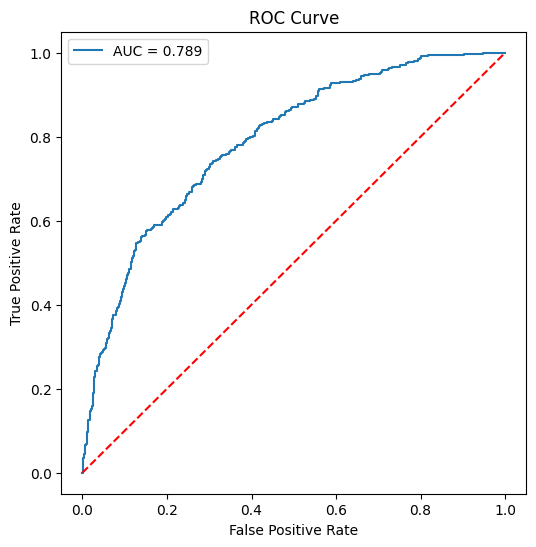

In [155]:
plt.figure(figsize=(6,6))
plt.plot(

    fpr,

    tpr,

    label="AUC = %.3f"%auc_score)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [157]:
feature_names = df.drop(["student_id", "completion_status", "final_score", "course_start_date"], axis=1).columns
importance = pd.DataFrame({

    "Feature":feature_names,

    "Importance":xgb_cls.feature_importances_})
importance = importance.sort_values(

    by="Importance",

    ascending=False)
importance.head(10)

,Feature,Importance
13,avg_quiz_score,0.150667
14,attendance_rate,0.131000
7,sessions,0.080695
8,time_spent_hours,0.070427
1,country_region,0.061730
9,videos_watched,0.054262
11,assignments_submitted,0.053559
0,age,0.053205
5,course_category,0.052281
12,forum_posts,0.050874


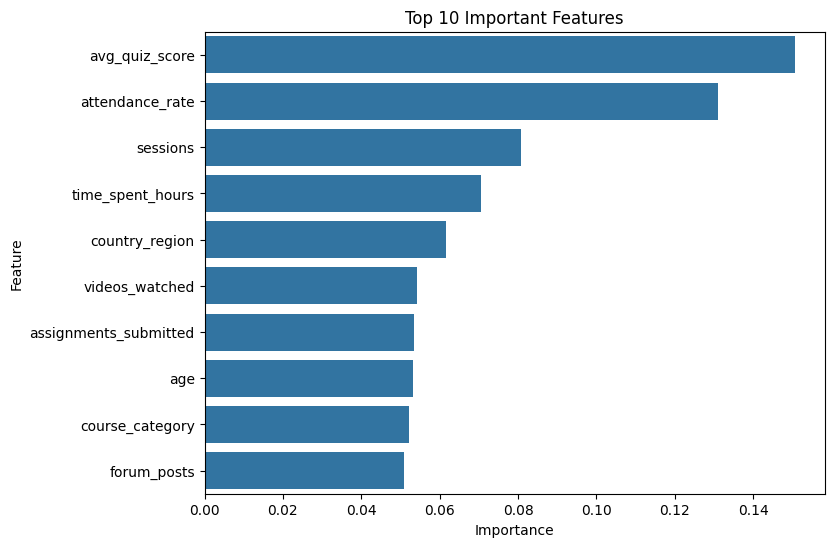

In [158]:
plt.figure(figsize=(8,6))
sns.barplot(

    data=importance.head(10),

    x="Importance",

    y="Feature")
plt.title("Top 10 Important Features")
plt.show()

In [159]:
best_cls = classification_results.sort_values(

    by="Accuracy",

    ascending=False)
best_cls

,Model,Accuracy,Precision,Recall,F1 Score
7,Stacking,0.743269,0.694006,0.564103,0.622348
6,Soft Voting,0.742308,0.682635,0.584615,0.629834
1,AdaBoost,0.734615,0.686275,0.538462,0.603448
4,XGBoost,0.734615,0.672727,0.569231,0.616667
2,Gradient Boosting,0.733654,0.670695,0.569231,0.615811
5,Hard Voting,0.717308,0.649068,0.535897,0.587079
0,Bagging,0.715385,0.635057,0.566667,0.598916
3,LightGBM,0.709615,0.623596,0.569231,0.595174


In [160]:
best_reg = regression_results.sort_values(

    by="R2 Score",

    ascending=False)
best_reg

,Model,MAE,RMSE,R2 Score
6,Stacking,7.877075,9.801083,0.485862
2,Gradient Boosting,7.886420,9.812431,0.484671
5,Voting,7.983534,9.873007,0.478289
3,LightGBM,7.964626,9.948562,0.470273
4,XGBoost,7.993186,9.991938,0.465644
0,Bagging,7.986036,10.003055,0.464454
1,AdaBoost,8.536461,10.514840,0.408252


1. Bagging reduced variance and improved model stability.

2. Boosting algorithms outperformed bagging in most cases by learning from previous errors.

3. Gradient Boosting, LightGBM, and XGBoost achieved higher predictive performance.

4. Voting combined multiple models effectively, while Stacking further improved performance using a meta-learner.

5. Among all classification models, the one with the highest Accuracy and F1-score was selected as the best classifier.

6. Among regression models, the one with the highest R² score and lowest RMSE was selected as the best regressor.

7. Ensemble learning significantly improved prediction accuracy compared to a single Decision Tree model.